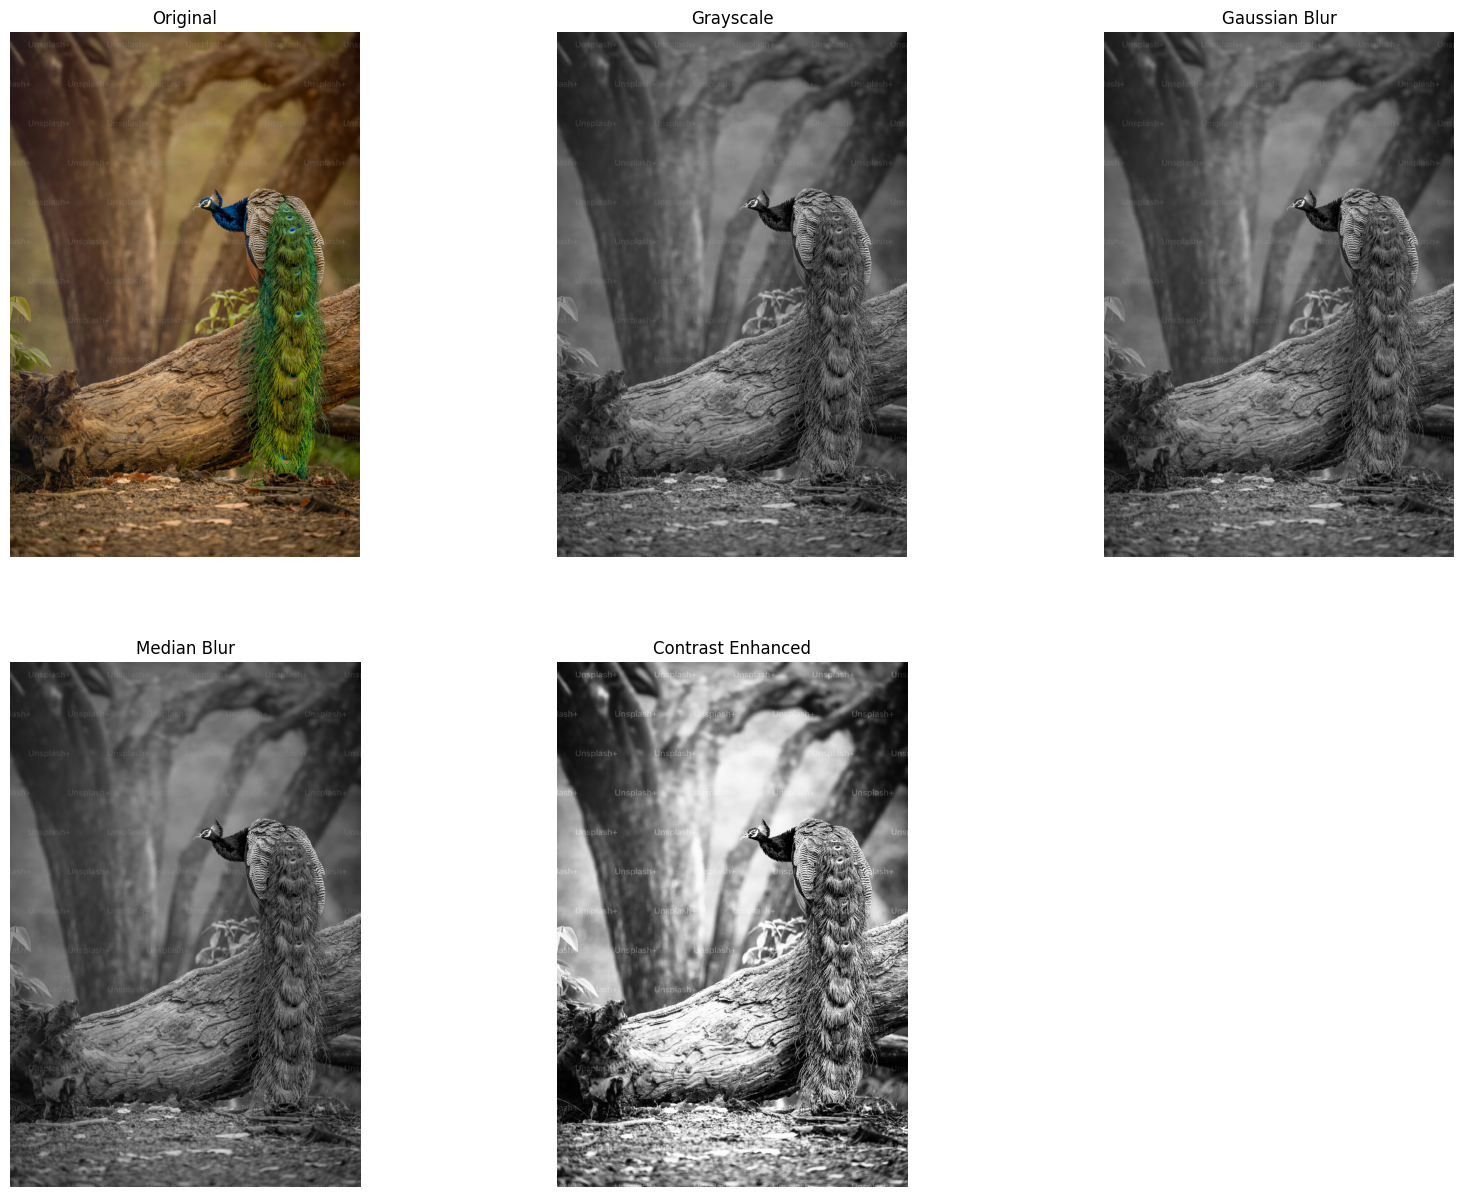

In [6]:
import cv2
import matplotlib.pyplot as plt

# Read image
img = cv2.imread('/content/wildlife.avif')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Noise removal (Gaussian + Median)
gaussian = cv2.GaussianBlur(gray, (5,5), 0)
median = cv2.medianBlur(gray, 5)

# Contrast enhancement (Histogram Equalization)
contrast = cv2.equalizeHist(gray)

# Display outputs
titles = ['Original', 'Grayscale', 'Gaussian Blur', 'Median Blur', 'Contrast Enhanced']
images = [img_rgb, gray, gaussian, median, contrast]

plt.figure(figsize=(20,15))
for i in range(5):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')
plt.show()

# **Feature Extraction**

# HOG

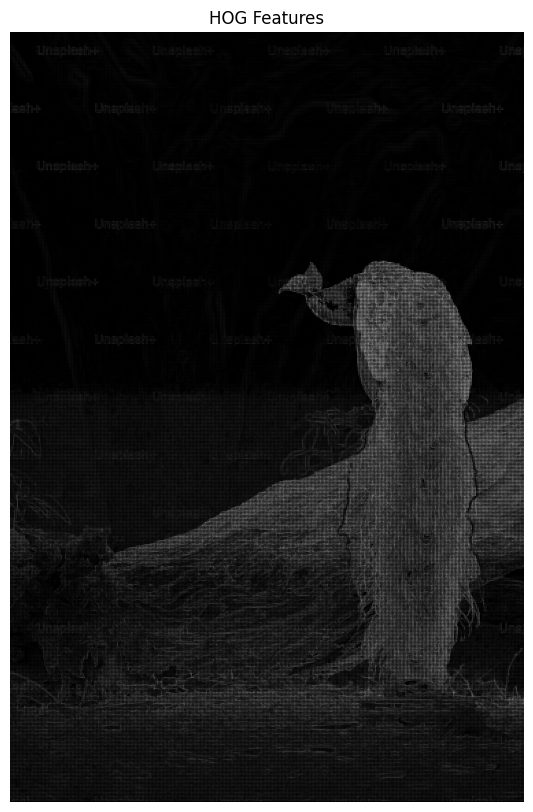

In [9]:
from skimage.feature import hog
from skimage import exposure

# HOG feature extraction
hog_features, hog_image = hog(gray, orientations=9, pixels_per_cell=(8,8),
                             cells_per_block=(2,2), visualize=True)

# Rescale for display
hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0,10))

# Display
plt.figure(figsize=(12,10))
plt.imshow(hog_image_rescaled, cmap='gray')
plt.title('HOG Features')
plt.axis('off')
plt.show()

# ORB

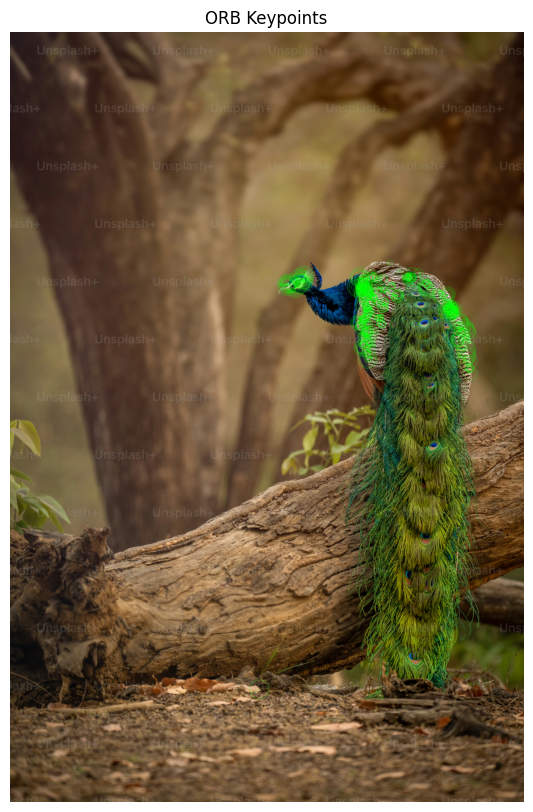

In [12]:
# ORB detector
orb = cv2.ORB_create()

# Detect keypoints and descriptors
kp, des = orb.detectAndCompute(gray, None)

# Draw keypoints
img_kp = cv2.drawKeypoints(
    img_rgb, kp, None,
    color=(0,255,0),
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)
# Display
plt.figure(figsize=(12,10))
plt.imshow(img_kp)
plt.title('ORB Keypoints')
plt.axis('off')
plt.show()

# Feature Matching

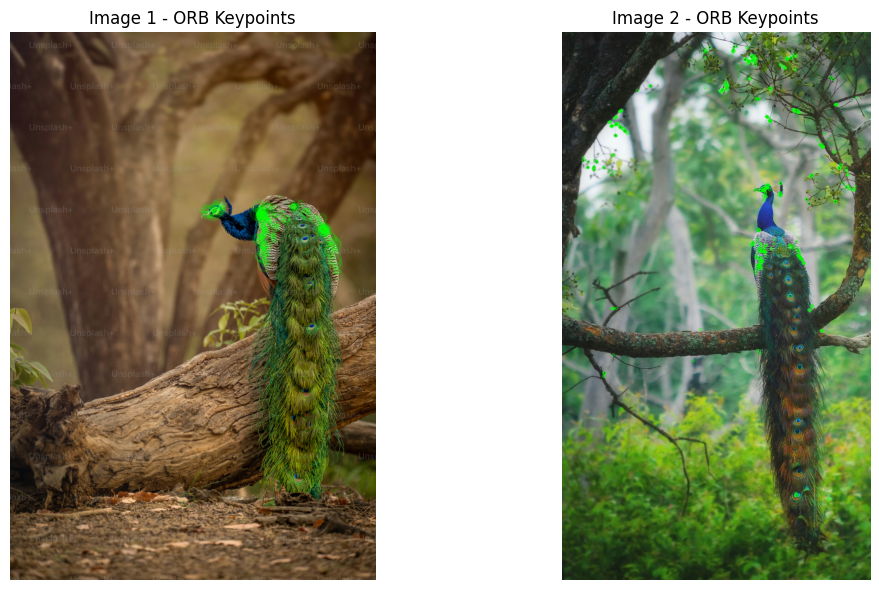

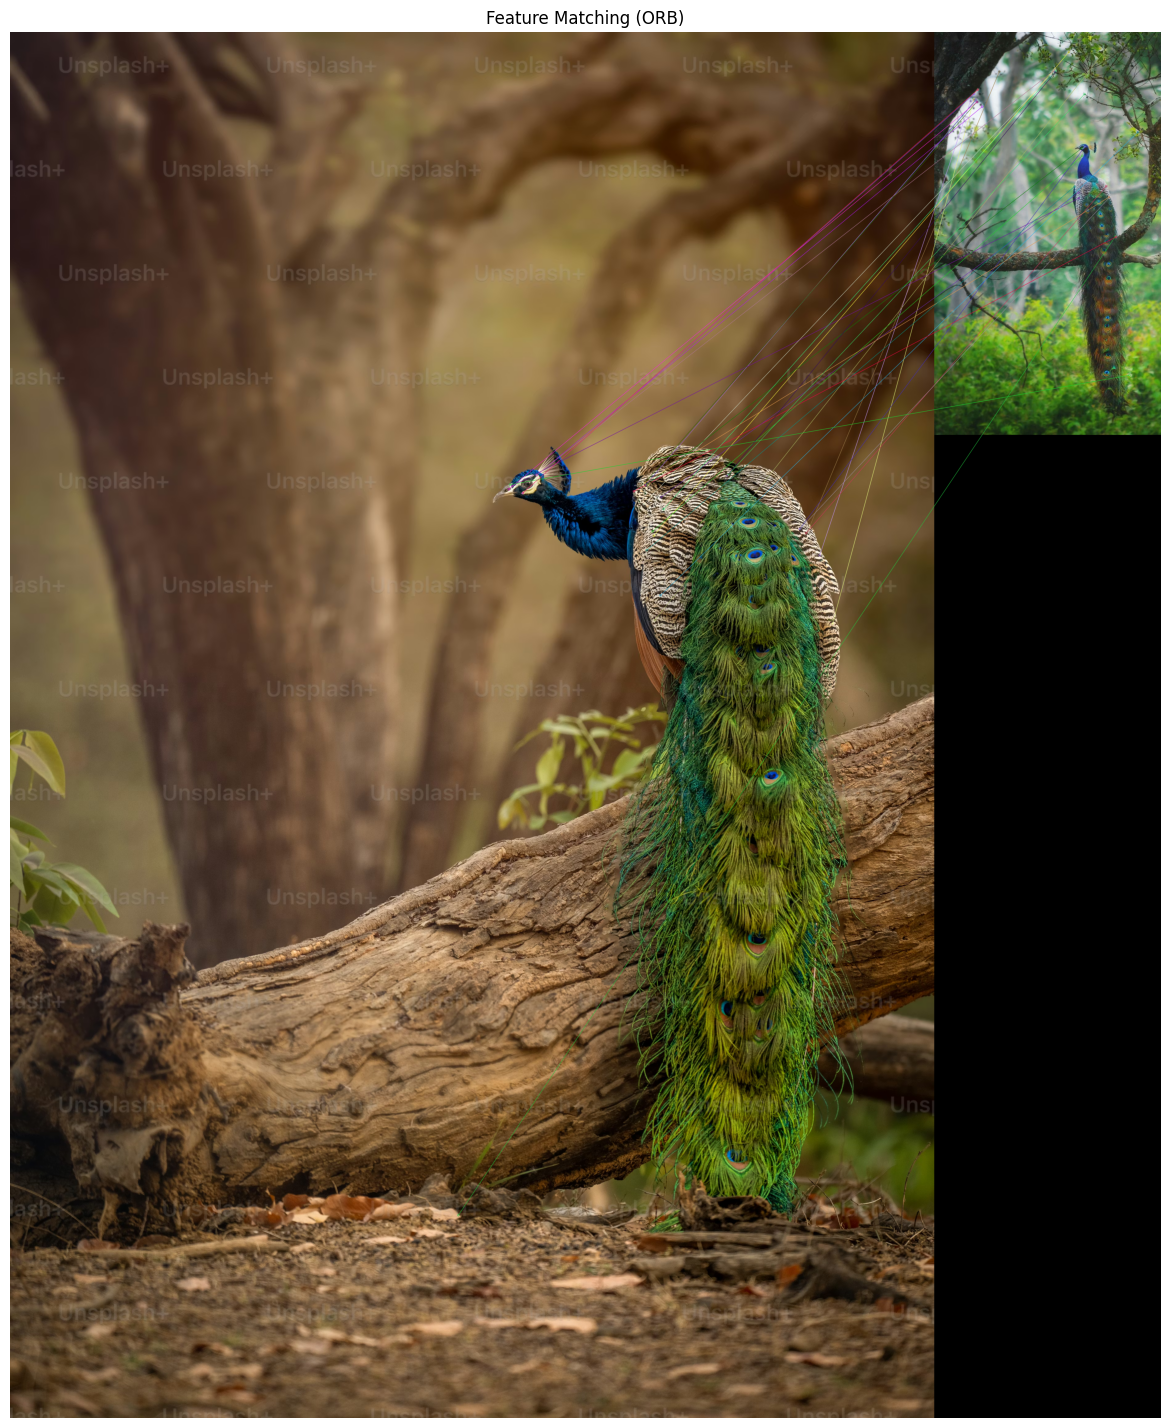

In [25]:
import cv2
import matplotlib.pyplot as plt

# Read the second image
img2 = cv2.imread('wildlife2.jpg')

# Convert to RGB for display
img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

# Convert to grayscale
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

kp2, des2 = orb.detectAndCompute(gray2, None)

# Draw keypoints
img2_kp = cv2.drawKeypoints(img2_rgb, kp2, None, color=(0,255,0))

# ✅ DISPLAY KEYPOINTS
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(img_kp)
plt.title("Image 1 - ORB Keypoints")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(img2_kp)
plt.title("Image 2 - ORB Keypoints")
plt.axis('off')

plt.tight_layout()
plt.show()


# ================= FEATURE MATCHING ================= #

# BFMatcher
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

# Match features
matches = bf.match(des, des2)

# Sort matches
matches = sorted(matches, key=lambda x: x.distance)

# Draw matches
matched_img = cv2.drawMatches(
    img, kp,
    img2, kp2,
    matches[:30],   # top matches
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

# Display matches
plt.figure(figsize=(20,18))
plt.imshow(cv2.cvtColor(matched_img, cv2.COLOR_BGR2RGB))
plt.title("Feature Matching (ORB)")
plt.axis('off')
plt.show()